In [162]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


In [163]:
df=pd.read_csv("/content/pcap.csv")

In [164]:
df = df.groupby('MalwareFamily', group_keys=False).apply( lambda x: x.sample( n=4000 if x.name == 'Benign' else min(len(x), 800),random_state=42 )).reset_index(drop=True)

/tmp/ipykernel_8123/3857148686.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('MalwareFamily', group_keys=False).apply( lambda x: x.sample( n=4000 if x.name == 'Benign' else min(len(x), 800),random_state=42 )).reset_index(drop=True)


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8812 entries, 0 to 8811
Data columns (total 42 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    8812 non-null   float64
 1   Protocol Type    8812 non-null   int64  
 2   Time_To_Live     8812 non-null   float64
 3   Rate             8812 non-null   float64
 4   fin_flag_number  8812 non-null   float64
 5   syn_flag_number  8812 non-null   float64
 6   rst_flag_number  8812 non-null   float64
 7   psh_flag_number  8812 non-null   float64
 8   ack_flag_number  8812 non-null   float64
 9   ece_flag_number  8812 non-null   float64
 10  cwr_flag_number  8812 non-null   float64
 11  ack_count        8812 non-null   int64  
 12  syn_count        8812 non-null   int64  
 13  fin_count        8812 non-null   int64  
 14  rst_count        8812 non-null   int64  
 15  HTTP             8812 non-null   float64
 16  HTTPS            8812 non-null   float64
 17  DNS           

In [166]:
df.nunique()

,0
Header_Length,93
Protocol Type,4
Time_To_Live,367
Rate,8289
fin_flag_number,6
syn_flag_number,16
rst_flag_number,11
psh_flag_number,7
ack_flag_number,14
ece_flag_number,1


In [167]:
"""df.sample(20, random_state=42)"""

'df.sample(20, random_state=42)'

In [168]:
df = df.drop(['Arch', 'Hash'], axis=1)

In [169]:
df.isnull().sum()

,0
Header_Length,0
Protocol Type,0
Time_To_Live,0
Rate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0
psh_flag_number,0
ack_flag_number,0
ece_flag_number,0


In [170]:
df['Variance'] = df['Variance'].fillna(df['Variance'].median())
df['Std'] = df['Std'].fillna(df['Std'].median())

In [171]:
df.isnull().sum()

,0
Header_Length,0
Protocol Type,0
Time_To_Live,0
Rate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0
psh_flag_number,0
ack_flag_number,0
ece_flag_number,0


In [172]:
df.shape

(8812, 40)

In [173]:
df.duplicated().sum()

np.int64(0)

In [174]:
df = df.drop_duplicates()

In [175]:
df['MalwareFamily'].value_counts()

,count
MalwareFamily,
Benign,4000
DarkNexus,800
Gafgyt,800
Generic,800
Unknown,800
Mirai,800
Tsunami,786
Agent,26


In [176]:
df = df[df['MalwareFamily'] != 'Unknown']

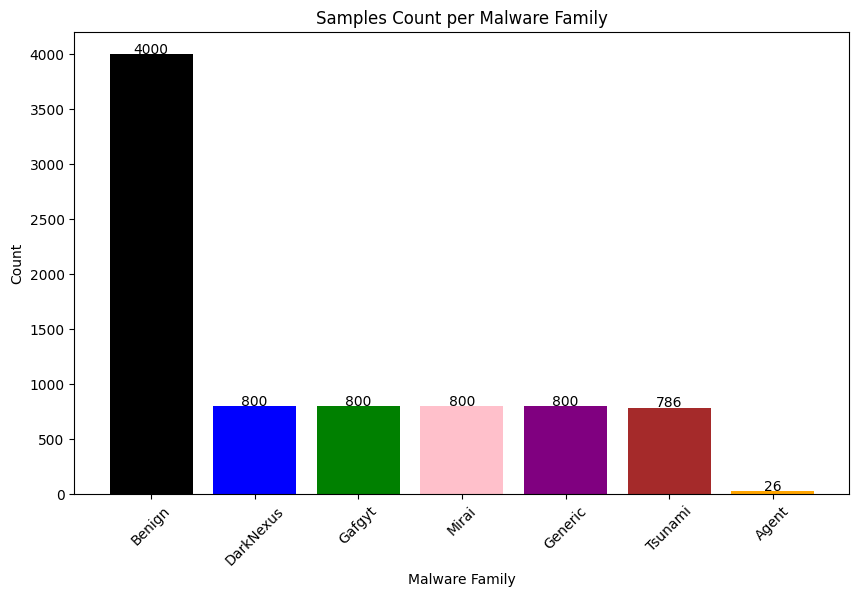

In [177]:
import matplotlib.pyplot as plt

counts = df['MalwareFamily'].value_counts()
colors = ['black', 'blue', 'green', 'pink', 'purple', 'brown', 'orange']
plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color=colors)

plt.title("Samples Count per Malware Family")
plt.xlabel("Malware Family")
plt.ylabel("Count")

plt.xticks(rotation=45)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 5,
             int(yval),
             ha='center')
plt.show()

In [178]:
df['Label'] = df['MalwareFamily'].apply(lambda x: 0 if x == 'Benign' else 1)

In [179]:
df['Label'].value_counts()

,count
Label,
1,4012
0,4000


In [180]:
df = df.drop('MalwareFamily', axis=1)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8012 entries, 0 to 8011
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    8012 non-null   float64
 1   Protocol Type    8012 non-null   int64  
 2   Time_To_Live     8012 non-null   float64
 3   Rate             8012 non-null   float64
 4   fin_flag_number  8012 non-null   float64
 5   syn_flag_number  8012 non-null   float64
 6   rst_flag_number  8012 non-null   float64
 7   psh_flag_number  8012 non-null   float64
 8   ack_flag_number  8012 non-null   float64
 9   ece_flag_number  8012 non-null   float64
 10  cwr_flag_number  8012 non-null   float64
 11  ack_count        8012 non-null   int64  
 12  syn_count        8012 non-null   int64  
 13  fin_count        8012 non-null   int64  
 14  rst_count        8012 non-null   int64  
 15  HTTP             8012 non-null   float64
 16  HTTPS            8012 non-null   float64
 17  DNS              80

In [182]:
df.nunique()

,0
Header_Length,89
Protocol Type,4
Time_To_Live,332
Rate,7555
fin_flag_number,6
syn_flag_number,14
rst_flag_number,10
psh_flag_number,7
ack_flag_number,13
ece_flag_number,1


In [183]:
df = df.drop(columns=[col for col in df.columns if df[col].nunique() <= 1])

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8012 entries, 0 to 8011
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    8012 non-null   float64
 1   Protocol Type    8012 non-null   int64  
 2   Time_To_Live     8012 non-null   float64
 3   Rate             8012 non-null   float64
 4   fin_flag_number  8012 non-null   float64
 5   syn_flag_number  8012 non-null   float64
 6   rst_flag_number  8012 non-null   float64
 7   psh_flag_number  8012 non-null   float64
 8   ack_flag_number  8012 non-null   float64
 9   ack_count        8012 non-null   int64  
 10  syn_count        8012 non-null   int64  
 11  fin_count        8012 non-null   int64  
 12  rst_count        8012 non-null   int64  
 13  HTTP             8012 non-null   float64
 14  HTTPS            8012 non-null   float64
 15  DNS              8012 non-null   float64
 16  Telnet           8012 non-null   float64
 17  TCP              80

In [185]:
df.corr()['Label']

,Label
Header_Length,0.906834
Protocol Type,-0.935156
Time_To_Live,0.282314
Rate,0.410607
fin_flag_number,0.112827
syn_flag_number,0.919685
rst_flag_number,0.258197
psh_flag_number,0.058020
ack_flag_number,0.230260
ack_count,0.230144


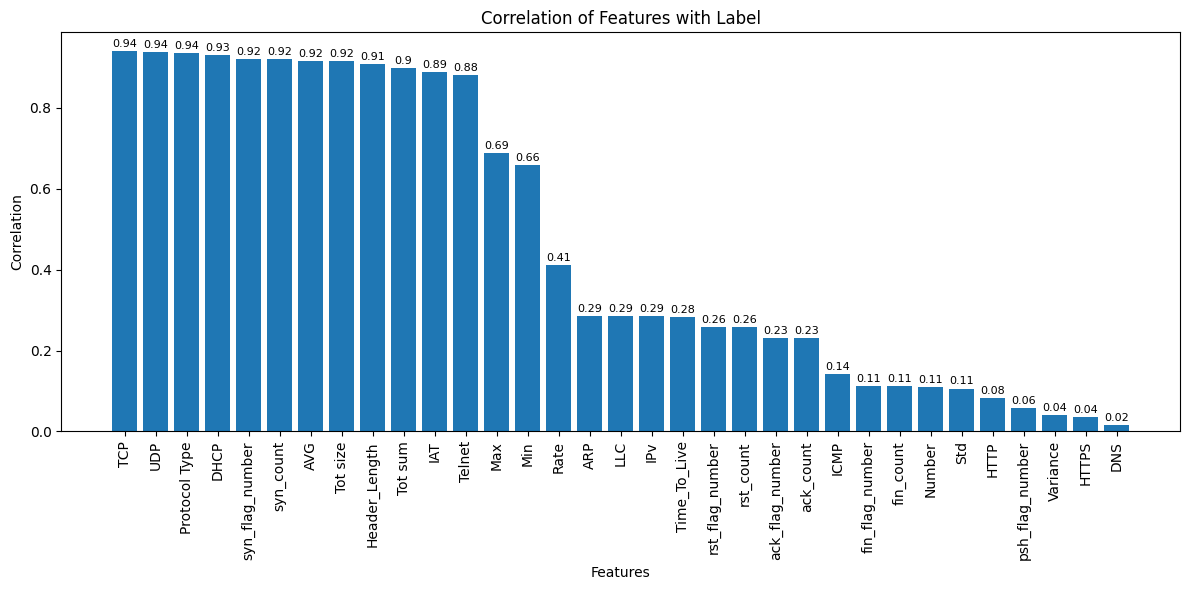

In [186]:
corr = df.corr(numeric_only=True)

target_corr = corr['Label'].abs().sort_values(ascending=False)

target_corr = target_corr.drop('Label')

plt.figure(figsize=(12,6))

bars = plt.bar(target_corr.index, target_corr.values)

plt.title("Correlation of Features with Label")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=90)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        round(yval, 2),
        ha='center',
        fontsize=8
    )
plt.tight_layout()
plt.show()

In [187]:

threshold = 0.2

low_corr_features = target_corr[target_corr < threshold].index.tolist()


df = df.drop(columns=low_corr_features)

print("Deleted Columns:")
print(low_corr_features)

print("\nRemaining Columns:")
print(df.columns)

Deleted Columns:
['ICMP', 'fin_flag_number', 'fin_count', 'Number', 'Std', 'HTTP', 'psh_flag_number', 'Variance', 'HTTPS', 'DNS']

Remaining Columns:
Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'syn_flag_number', 'rst_flag_number', 'ack_flag_number', 'ack_count',
       'syn_count', 'rst_count', 'Telnet', 'TCP', 'UDP', 'DHCP', 'ARP', 'IPv',
       'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Tot size', 'IAT', 'Label'],
      dtype='object')


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8012 entries, 0 to 8011
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    8012 non-null   float64
 1   Protocol Type    8012 non-null   int64  
 2   Time_To_Live     8012 non-null   float64
 3   Rate             8012 non-null   float64
 4   syn_flag_number  8012 non-null   float64
 5   rst_flag_number  8012 non-null   float64
 6   ack_flag_number  8012 non-null   float64
 7   ack_count        8012 non-null   int64  
 8   syn_count        8012 non-null   int64  
 9   rst_count        8012 non-null   int64  
 10  Telnet           8012 non-null   float64
 11  TCP              8012 non-null   float64
 12  UDP              8012 non-null   float64
 13  DHCP             8012 non-null   float64
 14  ARP              8012 non-null   float64
 15  IPv              8012 non-null   float64
 16  LLC              8012 non-null   float64
 17  Tot sum          80

In [189]:
df.shape

(8012, 24)

<Axes: ylabel='count'>

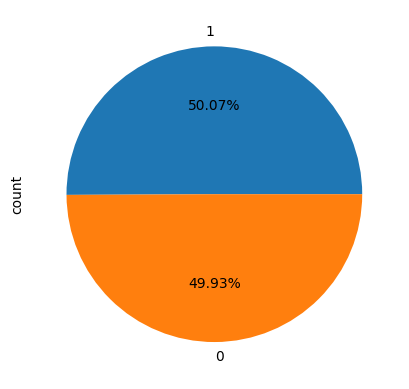

In [190]:
df['Label'].value_counts().plot.pie(autopct='%0.2f%%')

<Axes: xlabel='Label', ylabel='count'>

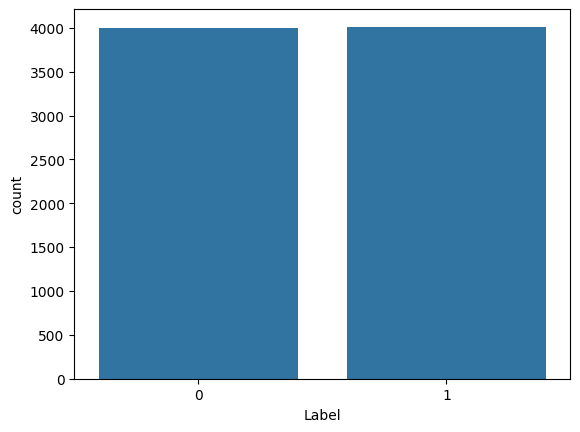

In [191]:
sns.countplot(x='Label', data=df)

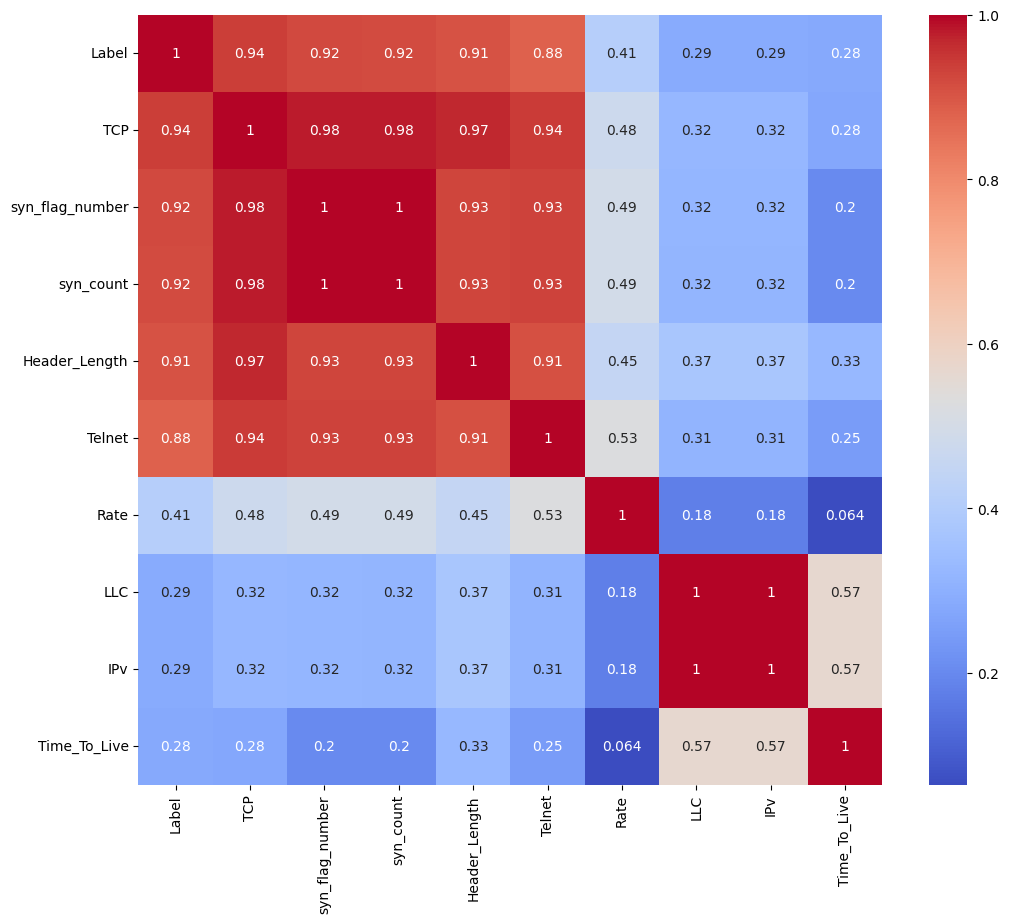

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
top_features = df.corr()['Label'].sort_values(ascending=False).head(10).index
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

In [193]:
X = df.drop("Label", axis=1)
y = df["Label"]
X = X.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



# ------------               RFC     ------------     

Confusion Matrix RFC:
 [[1200    0]
 [  43 1161]]
Accuracy: 0.9821131447587355
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       1.00      0.96      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



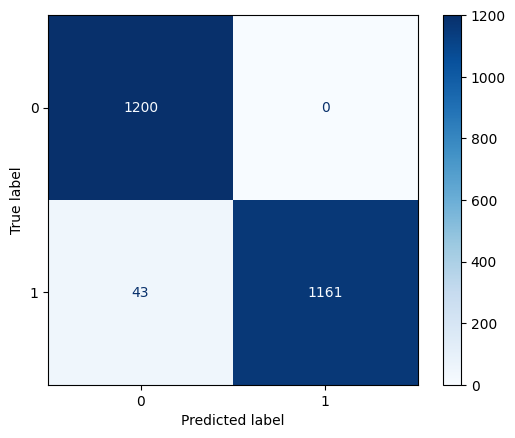

In [194]:

Rmodel = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

Rmodel.fit(X_train, y_train)
y_pred = Rmodel.predict(X_test)
cmR = confusion_matrix(y_test, y_pred)

print("Confusion Matrix RFC:\n", cmR)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cmR, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [195]:
train_pred = Rmodel.predict(X_train)
print("Training Accuracy RFC:", accuracy_score(y_train, train_pred))
print("Testing Accuracy  RFC :", accuracy_score(y_test, y_pred))

Training Accuracy RFC: 0.9816333808844507
Testing Accuracy  RFC : 0.9821131447587355




> # ------------               XGBOOST     ------------     



Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best Score: 0.9807400764214534
Confusion Matrix XGBOOST:
 [[1200    0]
 [  46 1158]]
Accuracy: 0.980865224625624
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1200
           1       1.00      0.96      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



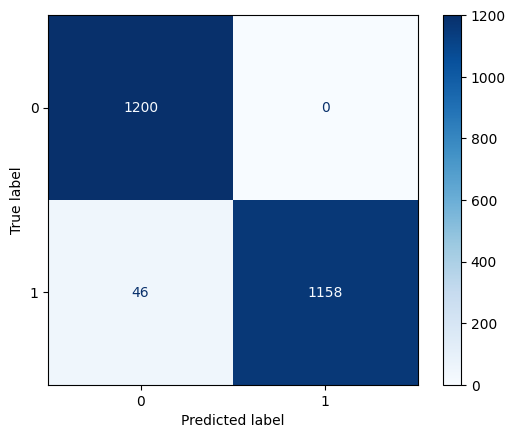

In [196]:

grid_parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.01, 0.2],
    'max_depth': [3, 5, 7]
}


grid_model = GridSearchCV(
    XGBClassifier(random_state=0),
    grid_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_model.fit(X_train, y_train)
print("Best Parameters:", grid_model.best_params_)
print("Best Score:", grid_model.best_score_)
y_pred = grid_model.predict(X_test)


y_pred = grid_model.predict(X_test)
cmG = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)



print("Confusion Matrix XGBOOST:\n", cmG)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cmG, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [197]:
train_pred = grid_model.predict(X_train)
print("Training Accuracy XGBOOST:", accuracy_score(y_train, train_pred))
print("Testing Accuracy XGBOOST:", accuracy_score(y_test, y_pred))

Training Accuracy XGBOOST: 0.9810984308131241
Testing Accuracy XGBOOST: 0.980865224625624


# ------------               SVM     ------------     

Accuracy SVM: 0.9621464226289518

Confusion Matrix:
 [[1179   21]
 [  70 1134]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      1200
           1       0.98      0.94      0.96      1204

    accuracy                           0.96      2404
   macro avg       0.96      0.96      0.96      2404
weighted avg       0.96      0.96      0.96      2404



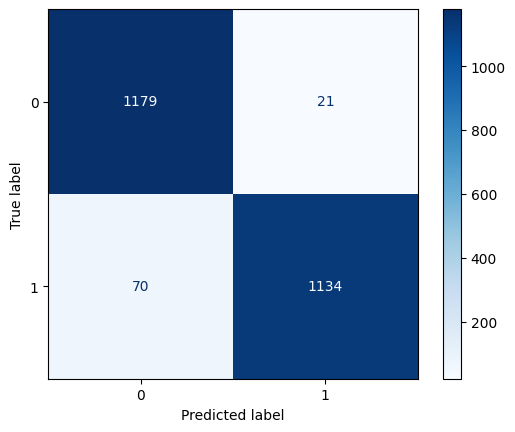

In [198]:

smodel = SVC(kernel='rbf', C=1.0, gamma='scale')
smodel.fit(X_train, y_train)
y_pred = smodel.predict(X_test)


CMS = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy SVM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMS, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [199]:
train_pred = smodel.predict(X_train)
print("Training Accuracy SVM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy SVM:", accuracy_score(y_test, y_pred))

Training Accuracy SVM: 0.9646932952924394
Testing Accuracy SVM: 0.9621464226289518




------------               Logistic Regression    ------------     

--- Logistic Regression Results ---
Training Accuracy LR: 0.9800285306704708
Testing Accuracy LR: 0.9792013311148087

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1200
           1       1.00      0.96      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



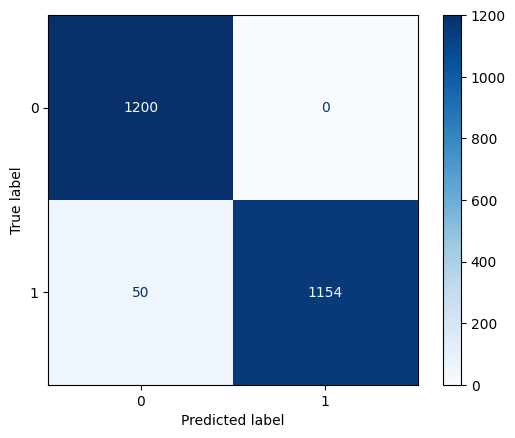

In [200]:
clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
train_pred = clf.predict(X_train)
CML = confusion_matrix(y_test, y_pred)

print("--- Logistic Regression Results ---")
print("Training Accuracy LR:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LR:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=CML, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [201]:
train_pred = clf.predict(X_train)
print("Training Accuracy LogisticRegression:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))

Training Accuracy LogisticRegression: 0.9800285306704708
Testing Accuracy LogisticRegression: 0.9792013311148087


# ------------               LightGBM    ------------

> Add blockquote



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2808, number of negative: 2800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1515
[LightGBM] [Info] Number of data points in the train set: 5608, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500713 -> initscore=0.002853
[LightGBM] [Info] Start training from score 0.002853
Accuracy  LightGBM: 0.9775374376039934

Confusion Matrix:
 [[1187   13]
 [  41 1163]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1200
           1       0.99      0.97      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98     

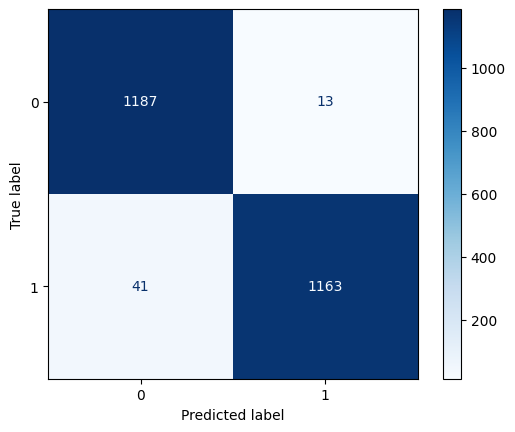

In [207]:


GBMmodel = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

GBMmodel.fit(X_train, y_train)

y_pred = GBMmodel.predict(X_test)
CMGBM = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  LightGBM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMGBM, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [208]:
train_pred = GBMmodel.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.9894793152639088
Testing Accuracy LightGBM: 0.9775374376039934


# ------------               Naïve Bayes ------------     

Accuracy  Naïve Bayes: 0.9779534109816972

Confusion Matrix:
 [[1189   11]
 [  42 1162]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1200
           1       0.99      0.97      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



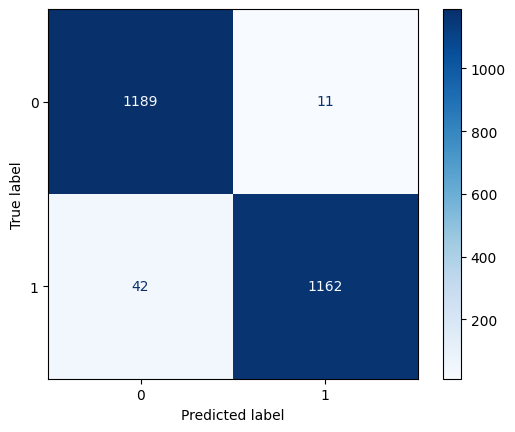

In [204]:
nb_model = GaussianNB(
    var_smoothing=1e-10
)

nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

CMnb = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  Naïve Bayes:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMnb, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()


In [205]:
train_pred = nb_model.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.9771754636233951
Testing Accuracy LightGBM: 0.9779534109816972


# download data

In [206]:
df.to_csv("sample_5000.csv", index=False)
from google.colab import files
files.download("sample_5000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>